<a href="https://colab.research.google.com/github/sjkim0520/Control_System/blob/main/SINDy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
SINDy (Sparse Identification of Nonlinear Dynamics)
=====================================================
Reference: Brunton, S. L., Proctor, J. L., & Kutz, J. N. (2016).
"Discovering governing equations from data by sparse identification
of nonlinear dynamical systems." PNAS, 113(15), 3932-3937.

이 스크립트는:
  1) Lorenz 시스템으로부터 시뮬레이션 데이터를 생성 (측정 데이터를 흉내)
  2) 다항식 후보 함수 라이브러리 Theta(X) 구성
  3) Sequential Thresholded Least Squares (STLSQ)로 희소 회귀 수행
  4) 식별된 지배방정식 계수를 출력하고, 원 시스템과 비교/검증

다른 비선형 시스템(예: 자체 로봇/모터 모델)에 적용하려면
lorenz() 함수와 true_coeffs 부분만 데이터 생성용으로 바꾸고,
실제로는 측정된 X, dX 데이터를 그대로 넣으면 됩니다.
"""

'\nSINDy (Sparse Identification of Nonlinear Dynamics)\n=====================================================\nReference: Brunton, S. L., Proctor, J. L., & Kutz, J. N. (2016).\n"Discovering governing equations from data by sparse identification\nof nonlinear dynamical systems." PNAS, 113(15), 3932-3937.\n \n이 스크립트는:\n  1) Lorenz 시스템으로부터 시뮬레이션 데이터를 생성 (측정 데이터를 흉내)\n  2) 다항식 후보 함수 라이브러리 Theta(X) 구성\n  3) Sequential Thresholded Least Squares (STLSQ)로 희소 회귀 수행\n  4) 식별된 지배방정식 계수를 출력하고, 원 시스템과 비교/검증\n \n다른 비선형 시스템(예: 자체 로봇/모터 모델)에 적용하려면\nlorenz() 함수와 true_coeffs 부분만 데이터 생성용으로 바꾸고,\n실제로는 측정된 X, dX 데이터를 그대로 넣으면 됩니다.\n'

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
#1. 데이터 생성 (실제 사용 시에는 센서로 측정한 X, dX로 대체)
def lorenz(t, state, sigma=10, rho=28, beta=8 / 3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]


def generate_data(dt=0.001, t_end=10, x0=(-8, 8, 27), noise_std=0.0):
    t_span = (0, t_end)
    t_eval = np.arange(0, t_end, dt)
    sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval, rtol=1e-11, atol=1e-11)
    X = sol.y.T  # shape (n_samples, n_states)

    # 노이즈가 있는 실제 측정 데이터를 흉내내고 싶으면 noise_std > 0으로 설정
    if noise_std > 0:
        X = X + np.random.normal(0, noise_std, X.shape)

    # 미분값(dX/dt)은 실제로는 유한차분(finite difference)으로 추정.
    # 여기서는 4th-order central difference 사용.
    dX = np.gradient(X, dt, axis=0)

    return t_eval, X, dX

In [ ]:
#2. 후보 함수 하리브러리 Theta(X) 구성 (다항식, 최대 2차)
def build_library(X, poly_order=2):
    n_samples, n_states = X.shape
    names = ["1"]
    cols = [np.ones((n_samples, 1))]

    # 1차항
    for i in range(n_states):
        cols.append(X[:, i:i + 1])
        names.append(f"x{i+1}")

    # 2차항
    if poly_order >= 2:
        for i in range(n_states):
            for j in range(i, n_states):
                cols.append((X[:, i] * X[:, j]).reshape(-1, 1))
                names.append(f"x{i+1}x{j+1}")

    Theta = np.hstack(cols)
    return Theta, names

In [ ]:
#3. Sequential Thresholded Least Squares (STLSQ) - 핵심 희소 회귀
def sparsify_dynamics(Theta, dX, lam=0.25, n_iters=10):
    #lam : 임계값(threshold). 값이 작으면 항이 더 많이 남고,
    #크면 더 희소한(단순한) 모델이 됨.

    n_features = Theta.shape[1]
    n_states = dX.shape[1]

    # 초기값: 최소자승 해
    Xi, *_ = np.linalg.lstsq(Theta, dX, rcond=None)

    for _ in range(n_iters):
        small_idx = np.abs(Xi) < lam
        Xi[small_idx] = 0
        for k in range(n_states):
            big_idx = ~small_idx[:, k]
            if np.any(big_idx):
                Xi[big_idx, k], *_ = np.linalg.lstsq(
                    Theta[:, big_idx], dX[:, k], rcond=None
                )
    return Xi


def print_equations(Xi, names, state_names=("x", "y", "z")):
    print("\n식별된 지배방정식:")
    for k, state in enumerate(state_names):
        terms = []
        for coef, name in zip(Xi[:, k], names):
            if abs(coef) > 1e-6:
                terms.append(f"{coef:+.3f}*{name}")
        eq = " ".join(terms) if terms else "0"
        print(f"d{state}/dt = {eq}")

In [ ]:
#4. 식별된 도멜로 순방향 시뮬레이션 (원 시스템과 비교)
def simulate_identified_model(Xi, names, x0, t_eval, poly_order=2):
    def rhs(t, state):
        X = np.array(state).reshape(1, -1)
        Theta, _ = build_library(X, poly_order=poly_order)
        return (Theta @ Xi).flatten()

    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval,
                     rtol=1e-8, atol=1e-8)
    return sol.y.T


식별된 지배방정식:
dx/dt = -10.000*x1 +10.000*x2
dy/dt = +27.998*x1 -1.000*x2 -1.000*x1x3
dz/dt = -2.667*x3 +1.000*x1x2

(참고) 실제 Lorenz 시스템 방정식:
dx/dt = -10.000*x +10.000*y
dy/dt = +28.000*x -1.000*y -1.000*xz
dz/dt = -2.667*z +1.000*xy


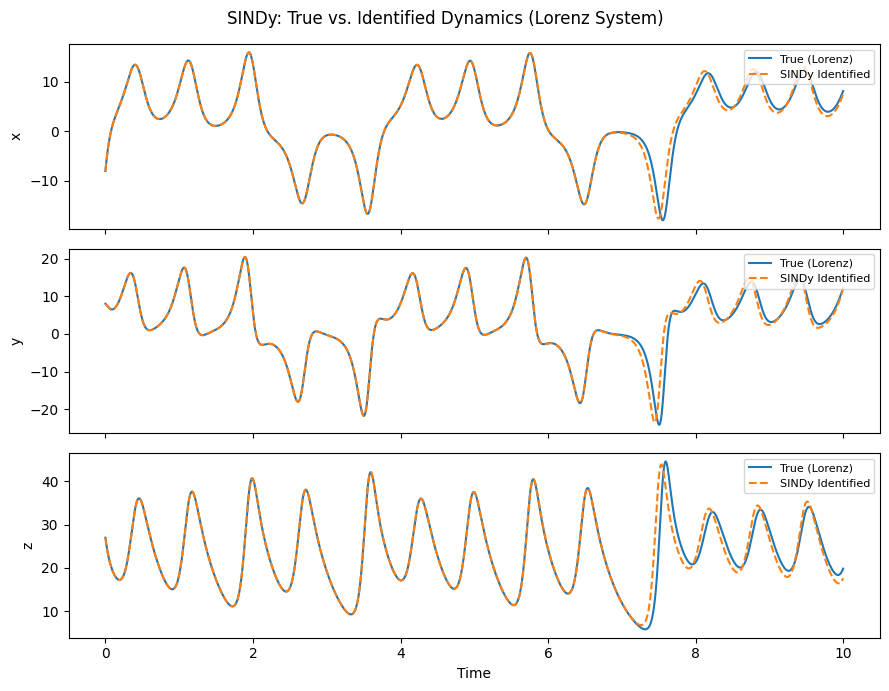

In [ ]:
#실행
if __name__ == "__main__":
    np.random.seed(0)

    # 1) 데이터 생성 (noise_std를 0보다 크게 주면 노이즈 강건성 테스트 가능)
    dt = 0.001
    t, X, dX = generate_data(dt=dt, t_end=10, noise_std=0.0)

    # 2) 라이브러리 구성
    Theta, names = build_library(X, poly_order=2)

    # 3) 희소 회귀
    Xi = sparsify_dynamics(Theta, dX, lam=0.25, n_iters=15)
    print_equations(Xi, names)

    print("\n(참고) 실제 Lorenz 시스템 방정식:")
    print("dx/dt = -10.000*x +10.000*y")
    print("dy/dt = +28.000*x -1.000*y -1.000*xz")
    print("dz/dt = -2.667*z +1.000*xy")

    # 4) 검증: 식별된 모델로 재시뮬레이션 후 비교
    t_test = np.arange(0, 10, dt)
    X_true = generate_data(dt=dt, t_end=10)[1]
    X_identified = simulate_identified_model(Xi, names, x0=(-8, 8, 27), t_eval=t_test)

    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    labels = ["x", "y", "z"]
    for i, ax in enumerate(axes):
        ax.plot(t_test, X_true[:, i], label="True (Lorenz)", lw=1.5)
        ax.plot(t_test, X_identified[:, i], "--", label="SINDy Identified", lw=1.5)
        ax.set_ylabel(labels[i])
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time")
    fig.suptitle("SINDy: True vs. Identified Dynamics (Lorenz System)")
    plt.tight_layout()
    plt.show()